<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Experience  21 non-null     float64
 1   Cost        21 non-null     float64
dtypes: float64(2)
memory usage: 468.0 bytes
0


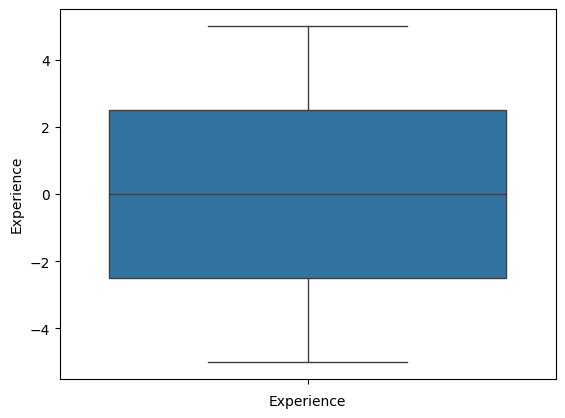

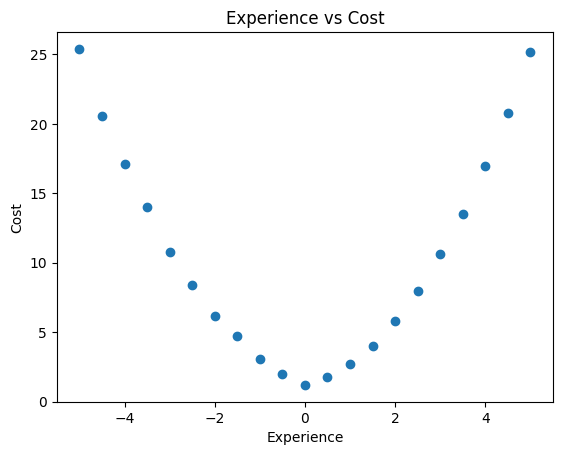

Number of instances for training: 16
Number of instances for testing: 5
Model Trained Successfully
    Actual  Predicted
4     10.8  10.347754
7      4.7   4.007067
5      8.4   7.764808
18    17.0  16.900413
3     14.0  13.400083
Mean Absolute Error (MAE): 0.22714726003630004
Mean Squared Error (MSE): 0.08252345528981678
Root MSE (RMSE): 0.28726895984393575
R2 Score: 0.9988396181630426
Mean Absolute Error (MAE): 0.4959750327642077
Mean Squared Error (MSE): 0.2915940220932553
Root MSE (RMSE): 0.5399944648727941
R2 Score: 0.9840638104399891


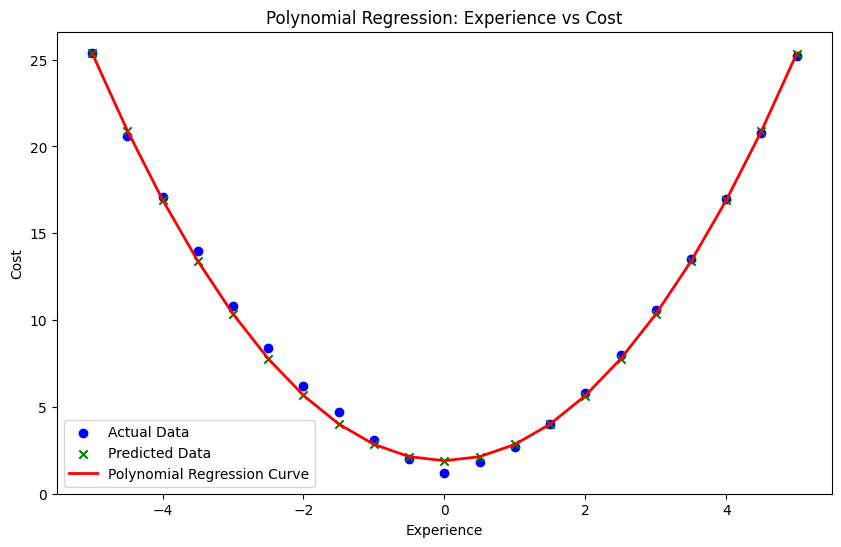

In [ ]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


# Read Dataset


dataset = pd.read_csv('/content/u_shaped_polynomial_regression(1).csv')



# Dataset Information


dataset.info()



# Statistical Summary


dataset.describe()



# Display First Five Rows

dataset.head()



# Display Dataset Shape


dataset.shape



# Display Dataset


dataset



# Check Duplicate Records


print(dataset.duplicated().sum())



# Outlier Detection


sns.boxplot(dataset['Experience'])

plt.xlabel('Experience')

plt.show()



# Define Independent and Dependent Variables


x = dataset['Experience']

y = dataset['Cost']


# Scatter Plot


plt.scatter(x, y)

plt.xlabel('Experience')

plt.ylabel('Cost')

plt.title('Experience vs Cost')

plt.show()



# Split the Dataset into Training and Testing Sets

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=123
)

print(
    f"Number of instances for training: {len(x_train)}"
)

print(
    f"Number of instances for testing: {len(x_test)}"
)



# Create Polynomial Features


poly_features = PolynomialFeatures(degree=2)

x_train_poly = poly_features.fit_transform(
    x_train.to_frame()
)


# Train Polynomial Regression Model

model = LinearRegression()

model.fit(
    x_train_poly,
    y_train
)

print("Model Trained Successfully")



# Transform Test Data


x_test_poly = poly_features.transform(
    x_test.to_frame()
)



# Generate Predictions


y_pred = model.predict(
    x_test_poly
)



# Display Actual and Predicted Values


df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(df)



# Evaluate Model Performance on Training Data


y_train_pred = model.predict(
    x_train_poly
)

mae = mean_absolute_error(
    y_train,
    y_train_pred
)

mse = mean_squared_error(
    y_train,
    y_train_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_train,
    y_train_pred
)

print(
    "Mean Absolute Error (MAE):",
    mae
)

print(
    "Mean Squared Error (MSE):",
    mse
)

print(
    "Root MSE (RMSE):",
    rmse
)

print(
    "R2 Score:",
    r2
)



# Evaluate Model Performance on Testing Data

y_test_pred = model.predict(
    x_test_poly
)

mae = mean_absolute_error(
    y_test,
    y_test_pred
)

mse = mean_squared_error(
    y_test,
    y_test_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_test_pred
)

print(
    "Mean Absolute Error (MAE):",
    mae
)

print(
    "Mean Squared Error (MSE):",
    mse
)

print(
    "Root MSE (RMSE):",
    rmse
)

print(
    "R2 Score:",
    r2
)



# Plot Actual Data


plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    color='blue',
    label='Actual Data'
)


=
# Plot Predicted Data
# Predict all X values
y_all_pred = model.predict(
    poly_features.transform(
        x.to_frame()
    )
)

plt.scatter(
    x,
    y_all_pred,
    color='green',
    marker='x',
    label='Predicted Data'
)



# Plot Polynomial Regression Curve


# Sort X values so that the curve is drawn correctly

x_sorted = np.sort(
    x.values
)

x_sorted_poly = poly_features.transform(
    pd.DataFrame({
        'Experience': x_sorted
    })
)

y_sorted_pred = model.predict(
    x_sorted_poly
)

plt.plot(
    x_sorted,
    y_sorted_pred,
    color='red',
    linewidth=2,
    label='Polynomial Regression Curve'
)


plt.xlabel('Experience')

plt.ylabel('Cost')

plt.title(
    'Polynomial Regression: Experience vs Cost'
)

plt.legend()

plt.show()